## setup

In [1]:
import os, cv2, shutil, random, glob
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from scipy.ndimage import gaussian_filter

In [50]:
F_DATA = "./data/heart"

F_DATA_ORIGINAL = F_DATA + "/original"
F_DATA_ORIGINAL_IMAGES = F_DATA_ORIGINAL + "/images"
F_DATA_ORIGINAL_MASKS = F_DATA_ORIGINAL + "/masks"

F_DATA_AUGMENTED_BRIGHTNESS = F_DATA + "/augmented_brightness"
F_DATA_AUGMENTED_BRIGHTNESS_IMAGES = F_DATA_AUGMENTED_BRIGHTNESS + "/images"
F_DATA_AUGMENTED_BRIGHTNESS_MASKS = F_DATA_AUGMENTED_BRIGHTNESS + "/masks"

F_DATA_AUGMENTED_TRADITIONAL = F_DATA + "/augmented_traditional"
F_DATA_AUGMENTED_TRADITIONAL_IMAGES = F_DATA_AUGMENTED_TRADITIONAL + "/images"
F_DATA_AUGMENTED_TRADITIONAL_MASKS = F_DATA_AUGMENTED_TRADITIONAL + "/masks"

F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS = F_DATA + "/augmented_traditional_brightness"
F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS_IMAGES = F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS + "/images"
F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS_MASKS = F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS + "/masks"

F_DATA_SYNTHETIC_CLEANED = "data/all/some-removed/original"
F_DATA_SYNTHETIC_CLEANED_IMAGES = F_DATA_SYNTHETIC_CLEANED + "/images"
F_DATA_SYNTHETIC_CLEANED_MASKS = F_DATA_SYNTHETIC_CLEANED + "/masks"

F_DATA_SYNTHETIC_CLEANED_TRADITIONAL = "data/all/some-removed/augmented-traditional"
F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_IMAGES = F_DATA_SYNTHETIC_CLEANED_TRADITIONAL + "/images"
F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_MASKS = F_DATA_SYNTHETIC_CLEANED_TRADITIONAL + "/masks"

F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS = "data/all/some-removed/augmented-traditional-brightness"
F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS_IMAGES = F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS + "/images"
F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS_MASKS = F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS + "/masks"

CSV_PATH_ORIGINAL = F_DATA + "/heart_original_data.csv"
CSV_PATH_AUGMENTED_BRIGHTNESS = F_DATA + "/heart_brightness_augmented_data.csv"
CSV_PATH_AUGMENTED_TRADITIONAL = F_DATA + "/heart_augmented_traditional_data.csv"
CSV_PATH_AUGMENTED_TRADITIONAL_BRIGHTNESS = F_DATA + "/heart_augmented_traditional_brightness_data.csv"
CSV_PATH_SYNTHETIC_CLEANED = F_DATA_SYNTHETIC_CLEANED + "/data.csv"
CSV_PATH_SYNTHETIC_CLEANED_TRADITIONAL = F_DATA_SYNTHETIC_CLEANED_TRADITIONAL + "/data.csv"
CSV_PATH_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS = F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS + "/data.csv"

In [51]:
class DataAugmenterBrightness:
    def __init__(self, csv_path, output_csv_path, f_original_images, f_original_masks, f_augmented_images, f_augmented_masks):
        self.csv_path = csv_path
        self.output_csv_path = output_csv_path
        self.f_original_images = f_original_images
        self.f_original_masks = f_original_masks
        self.f_augmented_images = f_augmented_images
        self.f_augmented_masks = f_augmented_masks

    def _empty_folder(self, folder):
        if os.path.exists(folder):
            shutil.rmtree(folder)
        os.makedirs(folder)

    def _crop_padding(self, img):
        if img is None:
            return None, None
        
        h, w = img.shape
        mean_rows = np.mean(img, axis=1)
        mean_cols = np.mean(img, axis=0)
        low_thresh, high_thresh = 15, 240

        rows_to_keep = (mean_rows >= low_thresh) & (mean_rows <= high_thresh)
        if np.any(rows_to_keep):
            first_row = np.argmax(rows_to_keep)
            last_row = len(rows_to_keep) - np.argmax(rows_to_keep[::-1]) - 1
        else:
            first_row, last_row = 0, h - 1
        
        cols_to_keep = (mean_cols >= low_thresh) & (mean_cols <= high_thresh)
        if np.any(cols_to_keep):
            first_col = np.argmax(cols_to_keep)
            last_col = len(cols_to_keep) - np.argmax(cols_to_keep[::-1]) - 1
        else:
            first_col, last_col = 0, w - 1
        
        crop_coords = (first_row, last_row, first_col, last_col)
        
        if last_row >= first_row and last_col >= first_col:
            cropped = img[first_row:last_row+1, first_col:last_col+1]
            return cropped, crop_coords
        else:
            return img, crop_coords

    def _restore_padding(self, cropped_img, crop_coords, original_shape):
        first_row, last_row, first_col, last_col = crop_coords
        h, w = original_shape
        
        restored = np.zeros((h, w), dtype=cropped_img.dtype)
        restored[first_row:last_row+1, first_col:last_col+1] = cropped_img
        
        return restored

    def _adjust_exposure_to_target(self, img, target_brightness, max_iter=50, tol=0.5):
        if target_brightness <= 0:
            beta = -255.0
        elif target_brightness >= 255:
            beta = 255.0
        else:
            low, high = -255.0, 255.0
            beta = 0.0
            
            for _ in range(max_iter):
                beta = (low + high) / 2.0
                adjusted = np.clip(img.astype(np.float32) + beta, 0, 255)
                new_brightness = adjusted.mean()
                
                if abs(new_brightness - target_brightness) < tol:
                    break
                    
                if new_brightness < target_brightness:
                    low = beta
                else:
                    high = beta
        
        adjusted = np.clip(img.astype(np.float32) + beta, 0, 255).astype(np.uint8)
        return adjusted

    def _adjust_black_to_target(self, img, target_brightness, max_iter=50, tol=0.5):        
        if target_brightness <= 0:
            value = -255.0
        elif target_brightness >= 255:
            value = 255.0
        else:
            low, high = -255.0, 255.0
            value = 0.0
            
            for _ in range(max_iter):
                value = (low + high) / 2.0
                
                lut = np.arange(256, dtype=np.float32)
                scale = 1 - (lut / 255)
                adjusted_lut = np.clip(lut + value * scale, 0, 255).astype(np.uint8)
                adjusted = cv2.LUT(img, adjusted_lut)
                
                new_brightness = adjusted.mean()
                
                if abs(new_brightness - target_brightness) < tol:
                    break
                    
                if new_brightness < target_brightness:
                    low = value
                else:
                    high = value
        
        lut = np.arange(256, dtype=np.float32)
        scale = 1 - (lut / 255)
        adjusted_lut = np.clip(lut + value * scale, 0, 255).astype(np.uint8)
        adjusted = cv2.LUT(img, adjusted_lut)
        return adjusted

    def _find_image_path(self, name, folder):
        for ext in ['.png', '.jpg', '.jpeg']:
            path = os.path.join(folder, name + ext)
            if os.path.exists(path):
                return path
        return None

    def _get_file_extension(self, filepath):
        return os.path.splitext(filepath)[1]

    def _create_ctr_groups(self, ctr_group_gap):
        groups = []
        start = 0.5
        
        current = start
        while current - ctr_group_gap >= 0:
            current -= ctr_group_gap
            groups.insert(0, (current, current + ctr_group_gap))
        
        current = start
        while current < 1.0:
            if current + ctr_group_gap <= 1.0:
                groups.append((current, current + ctr_group_gap))
            current += ctr_group_gap
        
        return groups

    def _create_brightness_groups(self, brightness_group_gap):
        groups = []
        current = 0
        while current < 255:
            end = min(current + brightness_group_gap, 255)
            groups.append((current, end))
            current = end
        return groups

    def _get_group_index(self, value, groups):
        for i, (start, end) in enumerate(groups):
            if start <= value < end:
                return i
        return -1

    def augment(self, copy_amount_dict, brightness_shift_limit, min_brightness_shift_limit, ctr_group_gap, brightness_group_gap, valid_brightness_range):
        df = pd.read_csv(self.csv_path)
        
        self._empty_folder(self.f_augmented_images)
        self._empty_folder(self.f_augmented_masks)
        
        ctr_groups = self._create_ctr_groups(ctr_group_gap)
        brightness_groups = self._create_brightness_groups(brightness_group_gap)
        
        current_brightness = []
        for _, row in df.iterrows():
            img_path = self._find_image_path(row['name'], self.f_original_images)
            if img_path:
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                cropped_img, _ = self._crop_padding(img)
                current_brightness.append(cropped_img.mean())
            else:
                current_brightness.append(row['brightness'])
        
        df['original_brightness'] = current_brightness
        
        ctr_group_counts = defaultdict(int)
        for _, row in df.iterrows():
            ctr_group_idx = self._get_group_index(row['ctr'], ctr_groups)
            if ctr_group_idx >= 0:
                ctr_group_counts[ctr_group_idx] += 1
        
        brightness_group_counts = defaultdict(int)
        for brightness in current_brightness:
            brightness_group_idx = self._get_group_index(brightness, brightness_groups)
            if brightness_group_idx >= 0:
                brightness_group_counts[brightness_group_idx] += 1
        
        output_data = []
        
        for _, row in df.iterrows():
            img_path = self._find_image_path(row['name'], self.f_original_images)
            mask_path = self._find_image_path(row['name'], self.f_original_masks)
            
            if img_path and mask_path:
                img_ext = self._get_file_extension(img_path)
                mask_ext = self._get_file_extension(mask_path)
                
                shutil.copy2(img_path, os.path.join(self.f_augmented_images, row['name'] + img_ext))
                shutil.copy2(mask_path, os.path.join(self.f_augmented_masks, row['name'] + mask_ext))
                
                row_data = row.to_dict()
                row_data['brightness'] = row['original_brightness']
                output_data.append(row_data)
        
        for _, row in df.iterrows():
            ctr_group_idx = self._get_group_index(row['ctr'], ctr_groups)
            if ctr_group_idx < 0:
                continue
            
            ctr_count = ctr_group_counts[ctr_group_idx]
            copies_to_make = 0
            
            for num_copies, (min_count, max_count) in copy_amount_dict.items():
                if min_count <= ctr_count <= max_count:
                    copies_to_make = num_copies
                    break
            
            if copies_to_make == 0:
                continue
            
            img_path = self._find_image_path(row['name'], self.f_original_images)
            mask_path = self._find_image_path(row['name'], self.f_original_masks)
            
            if not img_path or not mask_path:
                continue
            
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            original_shape = img.shape
            
            img_ext = self._get_file_extension(img_path)
            mask_ext = self._get_file_extension(mask_path)
            
            cropped_img, crop_coords = self._crop_padding(img)
            original_brightness = cropped_img.mean()
            
            min_brightness = max(valid_brightness_range[0], original_brightness - brightness_shift_limit)
            max_brightness = min(valid_brightness_range[1], original_brightness + brightness_shift_limit)
            
            available_groups = []
            for i, (start, end) in enumerate(brightness_groups):
                group_center = (start + end) / 2
                if (start >= min_brightness and end <= max_brightness and 
                    start >= valid_brightness_range[0] and end <= valid_brightness_range[1] and
                    abs(group_center - original_brightness) >= min_brightness_shift_limit):
                    available_groups.append(i)
            
            if not available_groups:
                continue
            
            for copy_idx in range(copies_to_make):
                available_groups.sort(key=lambda x: brightness_group_counts[x])
                
                target_group_idx = available_groups[copy_idx % len(available_groups)]
                group_start, group_end = brightness_groups[target_group_idx]
                
                target_brightness = np.random.uniform(
                    max(group_start, valid_brightness_range[0]), 
                    min(group_end, valid_brightness_range[1])
                )
                
                if target_brightness > original_brightness:
                    adjusted_cropped = self._adjust_exposure_to_target(cropped_img, target_brightness)
                else:
                    adjusted_cropped = self._adjust_black_to_target(cropped_img, target_brightness)
                
                adjusted_img = self._restore_padding(adjusted_cropped, crop_coords, original_shape)
                
                aug_name = f"{row['name']}-aug{copy_idx + 1}"
                aug_img_path = os.path.join(self.f_augmented_images, aug_name + img_ext)
                aug_mask_path = os.path.join(self.f_augmented_masks, aug_name + mask_ext)
                
                cv2.imwrite(aug_img_path, adjusted_img)
                cv2.imwrite(aug_mask_path, mask)
                
                brightness_group_counts[target_group_idx] += 1
                
                actual_brightness = adjusted_cropped.mean()
                
                row_data = row.to_dict()
                row_data['name'] = aug_name
                row_data['brightness'] = actual_brightness
                output_data.append(row_data)
        
        output_df = pd.DataFrame(output_data)
        output_df.to_csv(self.output_csv_path, index=False)
        
        print(f"Augmentation completed. Total images: {len(output_df)}")
        print(f"Original images: {len(df)}")
        print(f"Augmented images: {len(output_df) - len(df)}")

In [52]:
class DataAugmenterTraditional:
    def __init__(self, f_original_images, f_original_masks, f_augmented_images, f_augmented_masks, random_seed=42):
        self.f_original_images = f_original_images
        self.f_original_masks = f_original_masks
        self.f_augmented_images = f_augmented_images
        self.f_augmented_masks = f_augmented_masks
        
        # Create augmented directories if they don't exist
        os.makedirs(f_augmented_images, exist_ok=True)
        os.makedirs(f_augmented_masks, exist_ok=True)
        
        # Set random seed for reproducibility
        self.random_seed = random_seed
        np.random.seed(random_seed)
        random.seed(random_seed)
        
        # Get all image and mask files
        self.image_files = self._get_files(f_original_images)
        self.mask_files = self._get_files(f_original_masks)
        
        # Verify pairing
        self._verify_image_mask_pairing()
    
    def _get_files(self, folder_path):
        """Get all image files from folder"""
        extensions = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG']
        files = []
        for ext in extensions:
            files.extend(glob.glob(os.path.join(folder_path, ext)))
        return sorted(files)
    
    def _verify_image_mask_pairing(self):
        """Verify that each image has a corresponding mask"""
        image_basenames = {Path(f).stem for f in self.image_files}
        mask_basenames = {Path(f).stem for f in self.mask_files}
        
        if image_basenames != mask_basenames:
            missing_masks = image_basenames - mask_basenames
            missing_images = mask_basenames - image_basenames
            
            error_msg = ""
            if missing_masks:
                error_msg += f"Missing masks for images: {missing_masks}\n"
            if missing_images:
                error_msg += f"Missing images for masks: {missing_images}\n"
            
            raise ValueError(f"Image-mask pairing mismatch:\n{error_msg}")
    
    def _get_mask_path(self, image_path):
        """Get corresponding mask path for an image"""
        image_basename = Path(image_path).stem
        for mask_path in self.mask_files:
            if Path(mask_path).stem == image_basename:
                return mask_path
        raise ValueError(f"No mask found for image: {image_path}")
    
    def gaussian_blur(self, image, mask, sigma_range=(0.5, 2.0), kernel_size_range=(3, 9)):
        """
        Apply Gaussian blur to image only (mask unchanged)
        
        Args:
            image: Input image
            mask: Input mask (unchanged)
            sigma_range: Range of sigma values for Gaussian kernel
            kernel_size_range: Range of kernel sizes (must be odd)
        """
        # Random parameters
        sigma = np.random.uniform(sigma_range[0], sigma_range[1])
        kernel_size = np.random.choice(range(kernel_size_range[0], kernel_size_range[1] + 1, 2))  # Ensure odd
        
        # Apply Gaussian blur using OpenCV
        blurred_image = cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)
        
        return blurred_image, mask.copy()
    
    def grid_distortion(self, image, mask, grid_size_range=(8, 16), distortion_strength_range=(0.05, 0.1), 
                             distortion_type='random', smoothness_factor=2.5):
        """
        Apply smooth grid distortion to both image and mask
        
        Args:
            image: Input image
            mask: Input mask
            grid_size_range: Range of grid divisions per dimension (higher = smoother)
            distortion_strength_range: Range of distortion strength (0-1, lower = less blocky)
            distortion_type: 'random', 'wave', 'elastic'
            smoothness_factor: Smoothing factor for distortion field (higher = smoother)
        """
        h, w = image.shape[:2]
        
        # Random parameters - use finer grid for smoother distortion
        grid_size = np.random.randint(grid_size_range[0], grid_size_range[1] + 1)
        distortion_strength = np.random.uniform(distortion_strength_range[0], distortion_strength_range[1])
        
        # Create dense displacement field directly at full resolution
        y_coords, x_coords = np.mgrid[0:h, 0:w]
        
        # Apply distortion based on type
        if distortion_type == 'random':
            # Create smooth random displacement using multiple octaves
            dx = np.zeros((h, w))
            dy = np.zeros((h, w))
            
            # Multiple frequency components for smooth noise
            for octave in range(1, 4):
                freq = octave * grid_size / max(h, w)
                amplitude = distortion_strength * (1.0 / octave)
                
                # Generate smooth noise using sine waves
                phase_x = np.random.uniform(0, 2*np.pi)
                phase_y = np.random.uniform(0, 2*np.pi)
                
                dx += amplitude * w * np.sin(freq * 2 * np.pi * x_coords / w + phase_x) * \
                      np.cos(freq * 2 * np.pi * y_coords / h + phase_y)
                dy += amplitude * h * np.cos(freq * 2 * np.pi * x_coords / w + phase_x) * \
                      np.sin(freq * 2 * np.pi * y_coords / h + phase_y)
                       
        elif distortion_type == 'wave':
            # Smooth wave distortion - reduced effect
            wave_freq_x = np.random.uniform(0.2, 0.6)  # Reduced frequency
            wave_freq_y = np.random.uniform(0.2, 0.6)  # Reduced frequency
            phase_x = np.random.uniform(0, 2*np.pi)
            phase_y = np.random.uniform(0, 2*np.pi)
            
            # Reduced distortion strength by 5x
            dx = distortion_strength * w * 0.2 * np.sin(wave_freq_x * 2 * np.pi * y_coords / h + phase_x)
            dy = distortion_strength * h * 0.2 * np.sin(wave_freq_y * 2 * np.pi * x_coords / w + phase_y)
            
        elif distortion_type == 'elastic':
            # Elastic deformation with Gaussian smoothing
            alpha = distortion_strength * min(h, w) * 0.5
            sigma = smoothness_factor
            
            # Random displacement fields
            dx = np.random.uniform(-1, 1, (h, w)) * alpha
            dy = np.random.uniform(-1, 1, (h, w)) * alpha
            
            # Apply Gaussian smoothing for elastic effect
            dx = gaussian_filter(dx, sigma, mode='reflect')
            dy = gaussian_filter(dy, sigma, mode='reflect')
        
        # Apply additional smoothing to reduce blockiness
        if smoothness_factor > 0:
            dx = gaussian_filter(dx, smoothness_factor * 0.5, mode='reflect')
            dy = gaussian_filter(dy, smoothness_factor * 0.5, mode='reflect')
        
        # Create mapping coordinates
        map_x = (x_coords + dx).astype(np.float32)
        map_y = (y_coords + dy).astype(np.float32)
        
        # Ensure coordinates are within bounds
        map_x = np.clip(map_x, 0, w - 1)
        map_y = np.clip(map_y, 0, h - 1)
        
        # Apply distortion to image with smooth interpolation
        if len(image.shape) == 3:  # Color image
            distorted_image = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        else:  # Grayscale
            distorted_image = cv2.remap(image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
        
        # Apply distortion to mask with nearest neighbor to preserve exact colors
        if len(mask.shape) == 3:  # Color mask
            distorted_mask = cv2.remap(mask, map_x, map_y, cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
        else:  # Grayscale mask
            distorted_mask = cv2.remap(mask, map_x, map_y, cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
        
        return distorted_image, distorted_mask

    def edge_enhancement(self, image, mask, kernel_strength_range=(0.2, 0.3)):
        """
        Apply edge enhancement (sharpening) to image only (mask unchanged).
        Uses a basic Laplacian-like kernel for sharpening.
        
        Args:
            image: Input image.
            mask: Input mask (unchanged).
            kernel_strength_range: Range of kernel strength values (default: (0.2, 0.3)).
                                  Positive values create sharpening effect.
        """
        # Random strength from the specified range
        strength = np.random.uniform(kernel_strength_range[0], kernel_strength_range[1])
        
        # Define a base sharpening kernel (Laplacian-like)
        base_sharpening_kernel = np.array([
            [-1, -1, -1],
            [-1,  8, -1],
            [-1, -1, -1]
        ], dtype=np.float32)
        
        # Calculate high-frequency components (edges)
        laplacian = cv2.filter2D(image, cv2.CV_32F, base_sharpening_kernel) # Use float for intermediate calculation

        # Apply enhancement
        enhanced_image = image.astype(np.float32) + strength * laplacian
        
        # Ensure image values are within the valid range (0-255 for uint8)
        enhanced_image = np.clip(enhanced_image, 0, 255).astype(np.uint8)
        
        return enhanced_image, mask.copy()
    
    def clarity(self, image, mask, texture_strength_range=(1.5, 2.0), edge_emphasis_range=(0.2, 0.4)):
        """
        Enhance image clarity by emphasizing textures and fine details without altering color balance.
        Uses a combination of edge enhancement and local contrast adjustment.

        Args:
            image: Input image (mask remains unchanged).
            texture_strength_range: Range for texture enhancement (higher values boost midtone contrast).
            edge_emphasis_range: Range for edge sharpening (avoids over-sharpening artifacts).
        """
        # Convert to float for calculations
        enhanced = image.astype(np.float32) / 255.0

        # Random parameters for texture and edge enhancement
        texture_strength = np.random.uniform(texture_strength_range[0], texture_strength_range[1])
        edge_strength = np.random.uniform(edge_emphasis_range[0], edge_emphasis_range[1])

        # Step 1: Local contrast adjustment (texture emphasis)
        # Use CLAHE (Contrast Limited Adaptive Histogram Equalization) for localized contrast
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=texture_strength, tileGridSize=(8, 8))
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        texture_enhanced = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR).astype(np.float32) / 255.0

        # Step 2: Edge emphasis (sharpening)
        # Apply a Laplacian kernel to highlight edges without color shifts
        kernel = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]], dtype=np.float32)
        edges = cv2.filter2D(enhanced, -1, kernel)
        sharpened = np.clip(enhanced + edge_strength * edges, 0, 1)

        # Blend texture-enhanced and sharpened results
        final = np.clip((texture_enhanced * 0.7 + sharpened * 0.3) * 255, 0, 255).astype(np.uint8)

        return final, mask.copy()

    def zoom_translate(self, image, mask, 
                    zoom_range=(1.0, 1.1), 
                    translate_x_range=(-0.05, 0.05),
                    translate_y_range=(-0.05, 0.05)):
        """
        Zoom in and translate image/mask while maintaining full canvas coverage 
        and ensuring segmentation masks remain completely visible.
        
        Args:
            image: Input image (numpy array)
            mask: Input mask (numpy array)
            zoom_range: Tuple (min, max) zoom factor (>1.0)
            translate_x_range: Tuple (min, max) horizontal translation (% of width)
            translate_y_range: Tuple (min, max) vertical translation (% of height)
        """
        h, w = image.shape[:2]
        
        # Random parameters
        zoom_factor = np.random.uniform(zoom_range[0], zoom_range[1])
        tx = np.random.uniform(translate_x_range[0], translate_x_range[1])
        ty = np.random.uniform(translate_y_range[0], translate_y_range[1])
        
        # Calculate crop size (smaller = zoomed in)
        crop_w = int(w / zoom_factor)
        crop_h = int(h / zoom_factor)
        
        # Calculate center point with translation
        center_x = w/2 + tx * w
        center_y = h/2 + ty * h
        
        # Calculate safe boundaries to keep crop within image
        safe_x = max(crop_w/2, min(w - crop_w/2, center_x))
        safe_y = max(crop_h/2, min(h - crop_h/2, center_y))
        
        # Calculate final crop coordinates
        x1 = int(safe_x - crop_w/2)
        y1 = int(safe_y - crop_h/2)
        x2 = x1 + crop_w
        y2 = y1 + crop_h
        
        # Crop and resize
        cropped_img = image[y1:y2, x1:x2]
        cropped_mask = mask[y1:y2, x1:x2]
        
        # Resize to original dimensions
        zoomed_img = cv2.resize(cropped_img, (w, h), interpolation=cv2.INTER_LINEAR)
        zoomed_mask = cv2.resize(cropped_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        
        return zoomed_img, zoomed_mask


    def augment(self, copies_per_image=1, augmentation_probabilities=None):
        """
        Augment all images with different techniques, ensuring each image receives unique techniques per copy.
        
        Args:
            copies_per_image: Number of augmented copies per original image (original not included).
                            Each copy will undergo one *unique* chosen augmentation technique.
                            This value will be capped at the total number of available techniques.
            augmentation_probabilities: A dictionary where keys are augmentation method names (strings)
                                        and values are their probability weights (floats).
                                        If None, all available methods are chosen with equal probability weights.
                                        The weights will be used to select from *remaining unused* techniques.
        """
        # Clear target folders first
        if os.path.exists(self.f_augmented_images):
            shutil.rmtree(self.f_augmented_images)
        if os.path.exists(self.f_augmented_masks):
            shutil.rmtree(self.f_augmented_masks)
        
        # Recreate directories
        os.makedirs(self.f_augmented_images, exist_ok=True)
        os.makedirs(self.f_augmented_masks, exist_ok=True)
        
        # Available augmentation methods (including new clarity technique)
        all_augmentation_methods = ['gaussian_blur', 'grid_distortion', 'edge_enhancement', 'clarity', 'zoom_translate']
        
        # Determine the methods and their initial probability weights
        effective_augmentation_weights = {}
        if augmentation_probabilities:
            for method, weight in augmentation_probabilities.items():
                if hasattr(self, method) and callable(getattr(self, method)):
                    effective_augmentation_weights[method] = weight
                else:
                    print(f"Warning: Augmentation method '{method}' specified in probabilities "
                        "is not a valid method in DataAugmenterTraditional class. Skipping.")
            
            if not effective_augmentation_weights:
                raise ValueError("No valid augmentation methods found after filtering with provided probabilities.")
            print(f"Using augmentation methods with custom probability weights: {effective_augmentation_weights}")
        else:
            # If no probabilities are given, use all available methods with equal probability weights
            for method in all_augmentation_methods:
                effective_augmentation_weights[method] = 1.0
            print(f"Using all available augmentation methods with equal probability weights: {effective_augmentation_weights}")

        # Initialize technique usage counter
        technique_usage = {method: 0 for method in effective_augmentation_weights.keys()}
        
        # Cap copies_per_image to the number of available unique techniques
        max_techniques = len(effective_augmentation_weights)
        if copies_per_image > max_techniques:
            print(f"Capping copies_per_image to {max_techniques} (maximum unique techniques per image).")
        copies_per_image = min(copies_per_image, max_techniques)

        # Reset random seed for consistent results
        np.random.seed(self.random_seed)
        random.seed(self.random_seed)
        
        total_augmented = 0
        total_originals = 0
        
        for image_path in self.image_files:
            try:
                # Load image and mask
                image = cv2.imread(image_path)
                if image is None:
                    print(f"Warning: Could not load image {image_path}")
                    continue
                
                mask_path = self._get_mask_path(image_path)
                mask = cv2.imread(mask_path)
                if mask is None:
                    print(f"Warning: Could not load mask {mask_path}")
                    continue
                
                # Get original filename
                image_filename = Path(image_path).name
                mask_filename = Path(mask_path).name
                base_name = Path(image_path).stem
                image_ext = Path(image_path).suffix
                mask_ext = Path(mask_path).suffix
                
                # 1. Save original files with original names
                original_image_path = os.path.join(self.f_augmented_images, image_filename)
                original_mask_path = os.path.join(self.f_augmented_masks, mask_filename)
                
                cv2.imwrite(original_image_path, image)
                cv2.imwrite(original_mask_path, mask)
                total_originals += 1
                
                # Maintain a list of available techniques for this image and their weights
                # Make a copy to modify per image
                current_available_techniques = list(effective_augmentation_weights.keys())
                current_technique_weights = list(effective_augmentation_weights.values())

                # 2. Create augmented copies based on probabilities and uniqueness constraint
                for copy_idx in range(copies_per_image):
                    if not current_available_techniques:
                        # Should not happen if copies_per_image is capped correctly, but as a safeguard
                        print(f"Warning: No more unique techniques available for {base_name}. Stopping for this image.")
                        break

                    # Normalize weights for random choice from *remaining* techniques
                    total_current_weight = sum(current_technique_weights)
                    if total_current_weight == 0: # Avoid division by zero if all remaining weights are zero
                        chosen_method_name = random.choice(current_available_techniques)
                    else:
                        normalized_current_weights = [w / total_current_weight for w in current_technique_weights]
                        chosen_method_name = np.random.choice(current_available_techniques, p=normalized_current_weights)
                    
                    augmented_image = image.copy()
                    augmented_mask = mask.copy()
                    
                    # Get the method function
                    augmentation_function = getattr(self, chosen_method_name)
                    
                    # Apply specific augmentation method
                    augmented_image, augmented_mask = augmentation_function(
                        augmented_image, augmented_mask
                    )
                    
                    # Create filename with method suffix
                    method_suffix = chosen_method_name
                    aug_image_name = f"{base_name}_aug_{method_suffix}_{copy_idx}{image_ext}"
                    aug_mask_name = f"{base_name}_aug_{method_suffix}_{copy_idx}{mask_ext}"
                    
                    # Save augmented image and mask
                    aug_image_path = os.path.join(self.f_augmented_images, aug_image_name)
                    aug_mask_path = os.path.join(self.f_augmented_masks, aug_mask_name)
                    
                    cv2.imwrite(aug_image_path, augmented_image)
                    cv2.imwrite(aug_mask_path, augmented_mask)
                    
                    total_augmented += 1
                    technique_usage[chosen_method_name] += 1
                    
                    # Remove the chosen technique from the list of available techniques for this image
                    chosen_idx = current_available_techniques.index(chosen_method_name)
                    current_available_techniques.pop(chosen_idx)
                    current_technique_weights.pop(chosen_idx)
                    
            except Exception as e:
                print(f"Error processing {image_path}: {str(e)}")
                continue
        
        print(f"\nAugmentation complete!")
        print(f"Saved {total_originals} original image-mask pairs")
        print(f"Generated {total_augmented} augmented image-mask pairs")
        print(f"Total files in target folders: {total_originals + total_augmented} pairs")
        
        # Print technique usage statistics
        print("\nAugmentation technique usage counts:")
        for technique, count in technique_usage.items():
            print(f"- {technique}: {count} times ({count/total_augmented:.1%} of total augmentations)")
    
    def visualize_augmentation(self, technique='gaussian_blur', num_samples=3, **technique_params):
        """
        Visualize a specific augmentation technique on random samples
        
        Args:
            technique: Name of augmentation technique
            num_samples: Number of random samples to show
            **technique_params: Parameters for the specific technique
        """
        # Reset random seed for visualization
        np.random.seed(self.random_seed)
        
        # Select random samples
        sample_indices = np.random.choice(len(self.image_files), 
                                         min(num_samples, len(self.image_files)), 
                                         replace=False)
        
        fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)
        
        for i, idx in enumerate(sample_indices):
            try:
                # Load original image and mask
                image_path = self.image_files[idx]
                mask_path = self._get_mask_path(image_path)
                
                image = cv2.imread(image_path)
                mask = cv2.imread(mask_path)
                
                if image is None or mask is None:
                    print(f"Warning: Could not load {image_path} or {mask_path}")
                    continue
                
                # Convert BGR to RGB for display
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
                
                # Apply augmentation
                if technique == 'gaussian_blur':
                    aug_image, aug_mask = self.gaussian_blur(image, mask, **technique_params)
                elif technique == 'grid_distortion':
                    aug_image, aug_mask = self.grid_distortion(image, mask, **technique_params)
                elif technique == 'edge_enhancement':
                    aug_image, aug_mask = self.edge_enhancement(image, mask, **technique_params)
                elif technique == 'clarity':
                    aug_image, aug_mask = self.clarity(image, mask, **technique_params)
                elif technique == 'zoom_translate':
                    aug_image, aug_mask = self.zoom_translate(image, mask, **technique_params)
                else:
                    raise ValueError(f"Unknown technique: {technique}")
                
                # Convert augmented images to RGB
                aug_image_rgb = cv2.cvtColor(aug_image, cv2.COLOR_BGR2RGB)
                aug_mask_rgb = cv2.cvtColor(aug_mask, cv2.COLOR_BGR2RGB)
                
                # Plot
                axes[i, 0].imshow(image_rgb)
                axes[i, 0].set_title('Original Image')
                axes[i, 0].axis('off')
                
                axes[i, 1].imshow(mask_rgb)
                axes[i, 1].set_title('Original Mask')
                axes[i, 1].axis('off')
                
                axes[i, 2].imshow(aug_image_rgb)
                axes[i, 2].set_title(f'Augmented Image ({technique})')
                axes[i, 2].axis('off')
                
                axes[i, 3].imshow(aug_mask_rgb)
                axes[i, 3].set_title(f'Augmented Mask ({technique})')
                axes[i, 3].axis('off')
                
            except Exception as e:
                print(f"Error visualizing sample {idx}: {str(e)}")
                continue
        
        plt.tight_layout()
        plt.show()
    
    def get_augmentation_info(self):
        """Get information about available augmentation techniques and their parameters"""
        info = {
            'gaussian_blur': {
                'description': 'Apply Gaussian blur to image (mask unchanged)',
                'parameters': {
                    'sigma_range': 'Range of sigma values (default: (0.5, 2.0))',
                    'kernel_size_range': 'Range of kernel sizes, must be odd (default: (3, 9))'
                }
            },
            'grid_distortion': {
                'description': 'Apply smooth grid-based distortion to both image and mask',
                'parameters': {
                    'grid_size_range': 'Range of grid divisions, higher=smoother (default: (8, 16))',
                    'distortion_strength_range': 'Range of distortion strength 0-1, lower=less blocky (default: (0.05, 0.1))',
                    'distortion_type': 'Type of distortion: random, wave, elastic (default: random)',
                    'smoothness_factor': 'Smoothing factor for distortion field, higher=smoother (default: 2.5)'
                }
            },
            'edge_enhancement': {
                'description': 'Apply edge enhancement (sharpening) to image only (mask unchanged)',
                'parameters': {
                    'kernel_strength_range': 'Range of kernel strength values (default: (0.2, 0.3))'
                }
            },
            'clarity': {
                'description': 'Enhances texture and fine details without affecting color balance. Ideal for emphasizing midtone contrast and edges.',
                'parameters': {
                    'texture_strength_range': 'Controls local contrast (default: (1.5, 2.0)). Higher values emphasize textures.',
                    'edge_emphasis_range': 'Strength of edge sharpening (default: (0.2, 0.4)). Avoids over-sharpening.'
                }
            },
            'zoom_translate': {
                'description': 'Zoom in and translate viewpoint while maintaining full canvas coverage',
                'parameters': {
                    'zoom_range': 'Range of zoom factors (default: (1.0, 1.1))',
                    'translate_x_range': 'Horizontal translation range as fraction of width (default: (-0.05, 0.05))',
                    'translate_y_range': 'Vertical translation range as fraction of height (default: (-0.05, 0.05))'
                }
            }
        }
        return info

## augment original data by adjusting brightness

In [ ]:
data_augmenter_brightness = DataAugmenterBrightness(
    CSV_PATH_ORIGINAL, CSV_PATH_AUGMENTED_BRIGHTNESS,
    F_DATA_ORIGINAL_IMAGES, F_DATA_ORIGINAL_MASKS,
    F_DATA_AUGMENTED_BRIGHTNESS_IMAGES, F_DATA_AUGMENTED_BRIGHTNESS_MASKS
    )

In [5]:
copy_amount_dict = {
    7: (1,5),
    5: (6,10),
    2: (11,15),
    1: (16,20)
}
brightness_shift_limit = 50
min_brightness_shift_limit = 20
ctr_group_gap = 0.01
brightness_group_gap = 5
valid_brightness_range = (91, 224)

In [ ]:
data_augmenter_brightness.augment(
    copy_amount_dict=copy_amount_dict,
    brightness_shift_limit=brightness_shift_limit,
    min_brightness_shift_limit=min_brightness_shift_limit,
    ctr_group_gap=ctr_group_gap,
    brightness_group_gap=brightness_group_gap,
    valid_brightness_range=valid_brightness_range
    )

Augmentation completed. Total images: 1025
Original images: 383
Augmented images: 642


## augment original data by traditional methods

### setup

In [28]:
data_augmenter_traditional = DataAugmenterTraditional(
    F_DATA_ORIGINAL_IMAGES, F_DATA_ORIGINAL_MASKS,
    F_DATA_AUGMENTED_TRADITIONAL_IMAGES, F_DATA_AUGMENTED_TRADITIONAL_MASKS
    )

In [16]:
data_augmenter_traditional.get_augmentation_info()

{'gaussian_blur': {'description': 'Apply Gaussian blur to image (mask unchanged)',
  'parameters': {'sigma_range': 'Range of sigma values (default: (0.5, 2.0))',
   'kernel_size_range': 'Range of kernel sizes, must be odd (default: (3, 9))'}},
 'grid_distortion': {'description': 'Apply smooth grid-based distortion to both image and mask',
  'parameters': {'grid_size_range': 'Range of grid divisions, higher=smoother (default: (8, 16))',
   'distortion_strength_range': 'Range of distortion strength 0-1, lower=less blocky (default: (0.05, 0.1))',
   'distortion_type': 'Type of distortion: random, wave, elastic (default: random)',
   'smoothness_factor': 'Smoothing factor for distortion field, higher=smoother (default: 2.5)'}},
 'edge_enhancement': {'description': 'Apply edge enhancement (sharpening) to image only (mask unchanged)',
  'parameters': {'kernel_strength_range': 'Range of kernel strength values (default: (0.2, 0.3))'}},
 'clarity': {'description': 'Enhances texture and fine det

### visualizations

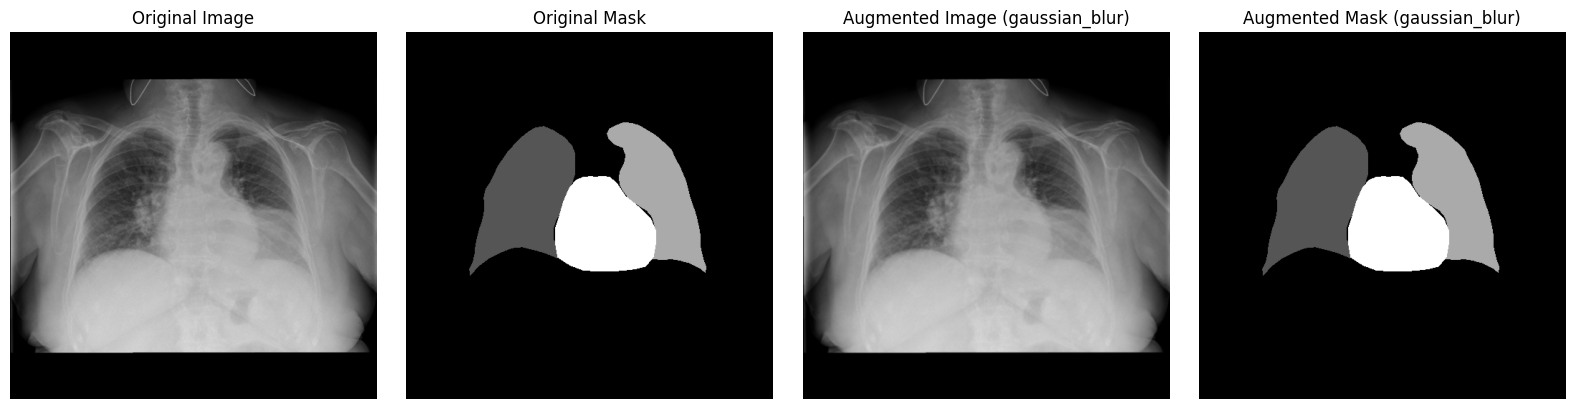

In [16]:
data_augmenter_traditional.visualize_augmentation(technique='gaussian_blur', num_samples=1, sigma_range=(0.5, 0.5), kernel_size_range=(3, 9))

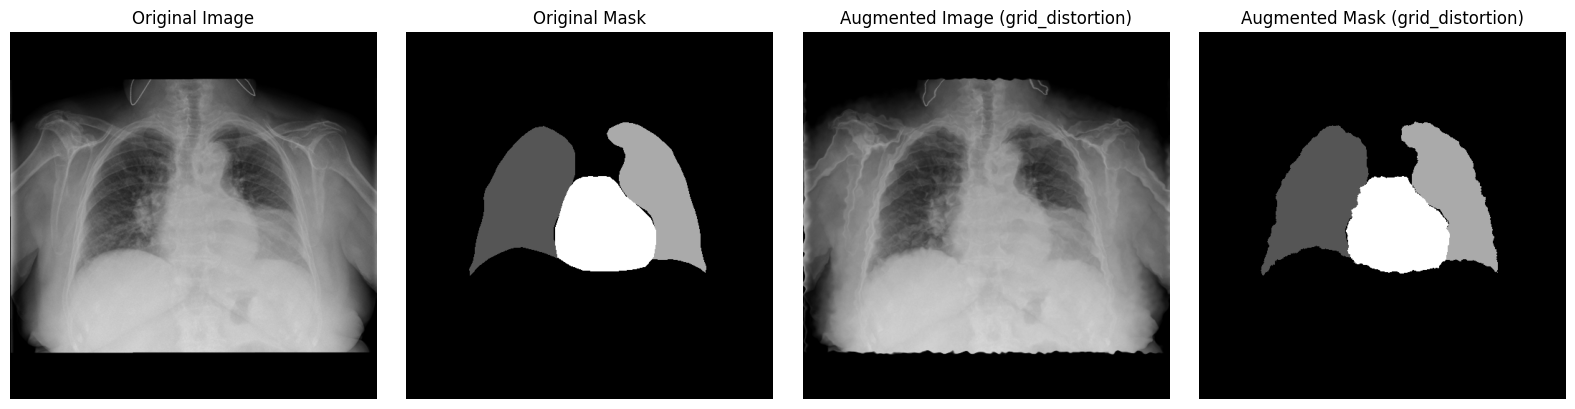

In [17]:
data_augmenter_traditional.visualize_augmentation(technique='grid_distortion', num_samples=1, distortion_type='elastic', grid_size_range=(8,16), distortion_strength_range=(0.05, 0.10), smoothness_factor=2.5)

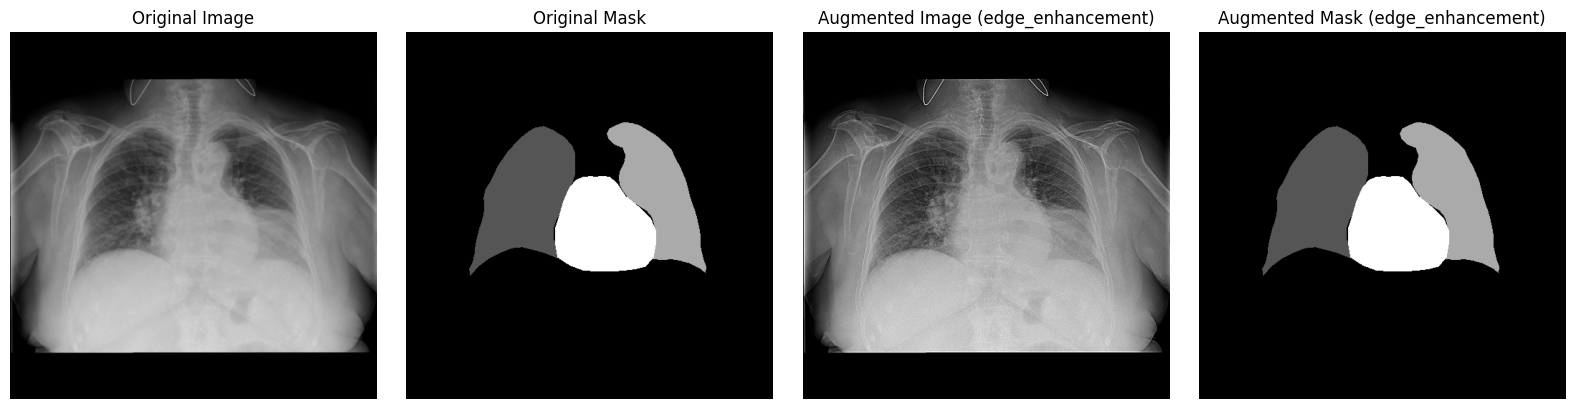

In [19]:
data_augmenter_traditional.visualize_augmentation(technique='edge_enhancement', num_samples=1, kernel_strength_range=(0.2, 0.3))

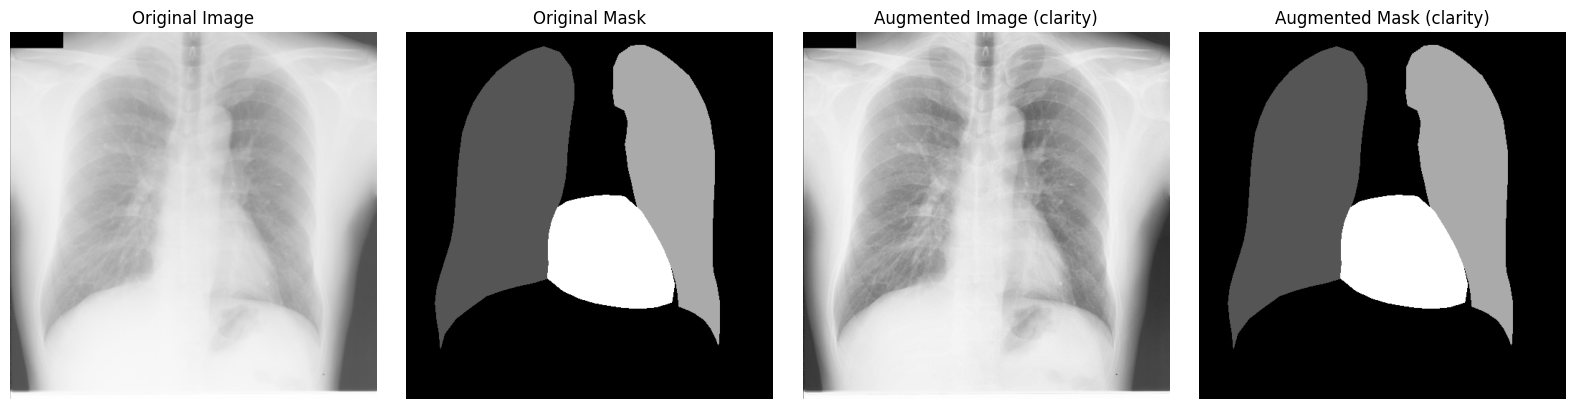

In [13]:
data_augmenter_traditional.visualize_augmentation(technique='clarity', num_samples=1, texture_strength_range=(1.5, 2.0), edge_emphasis_range=(0.2, 0.4))

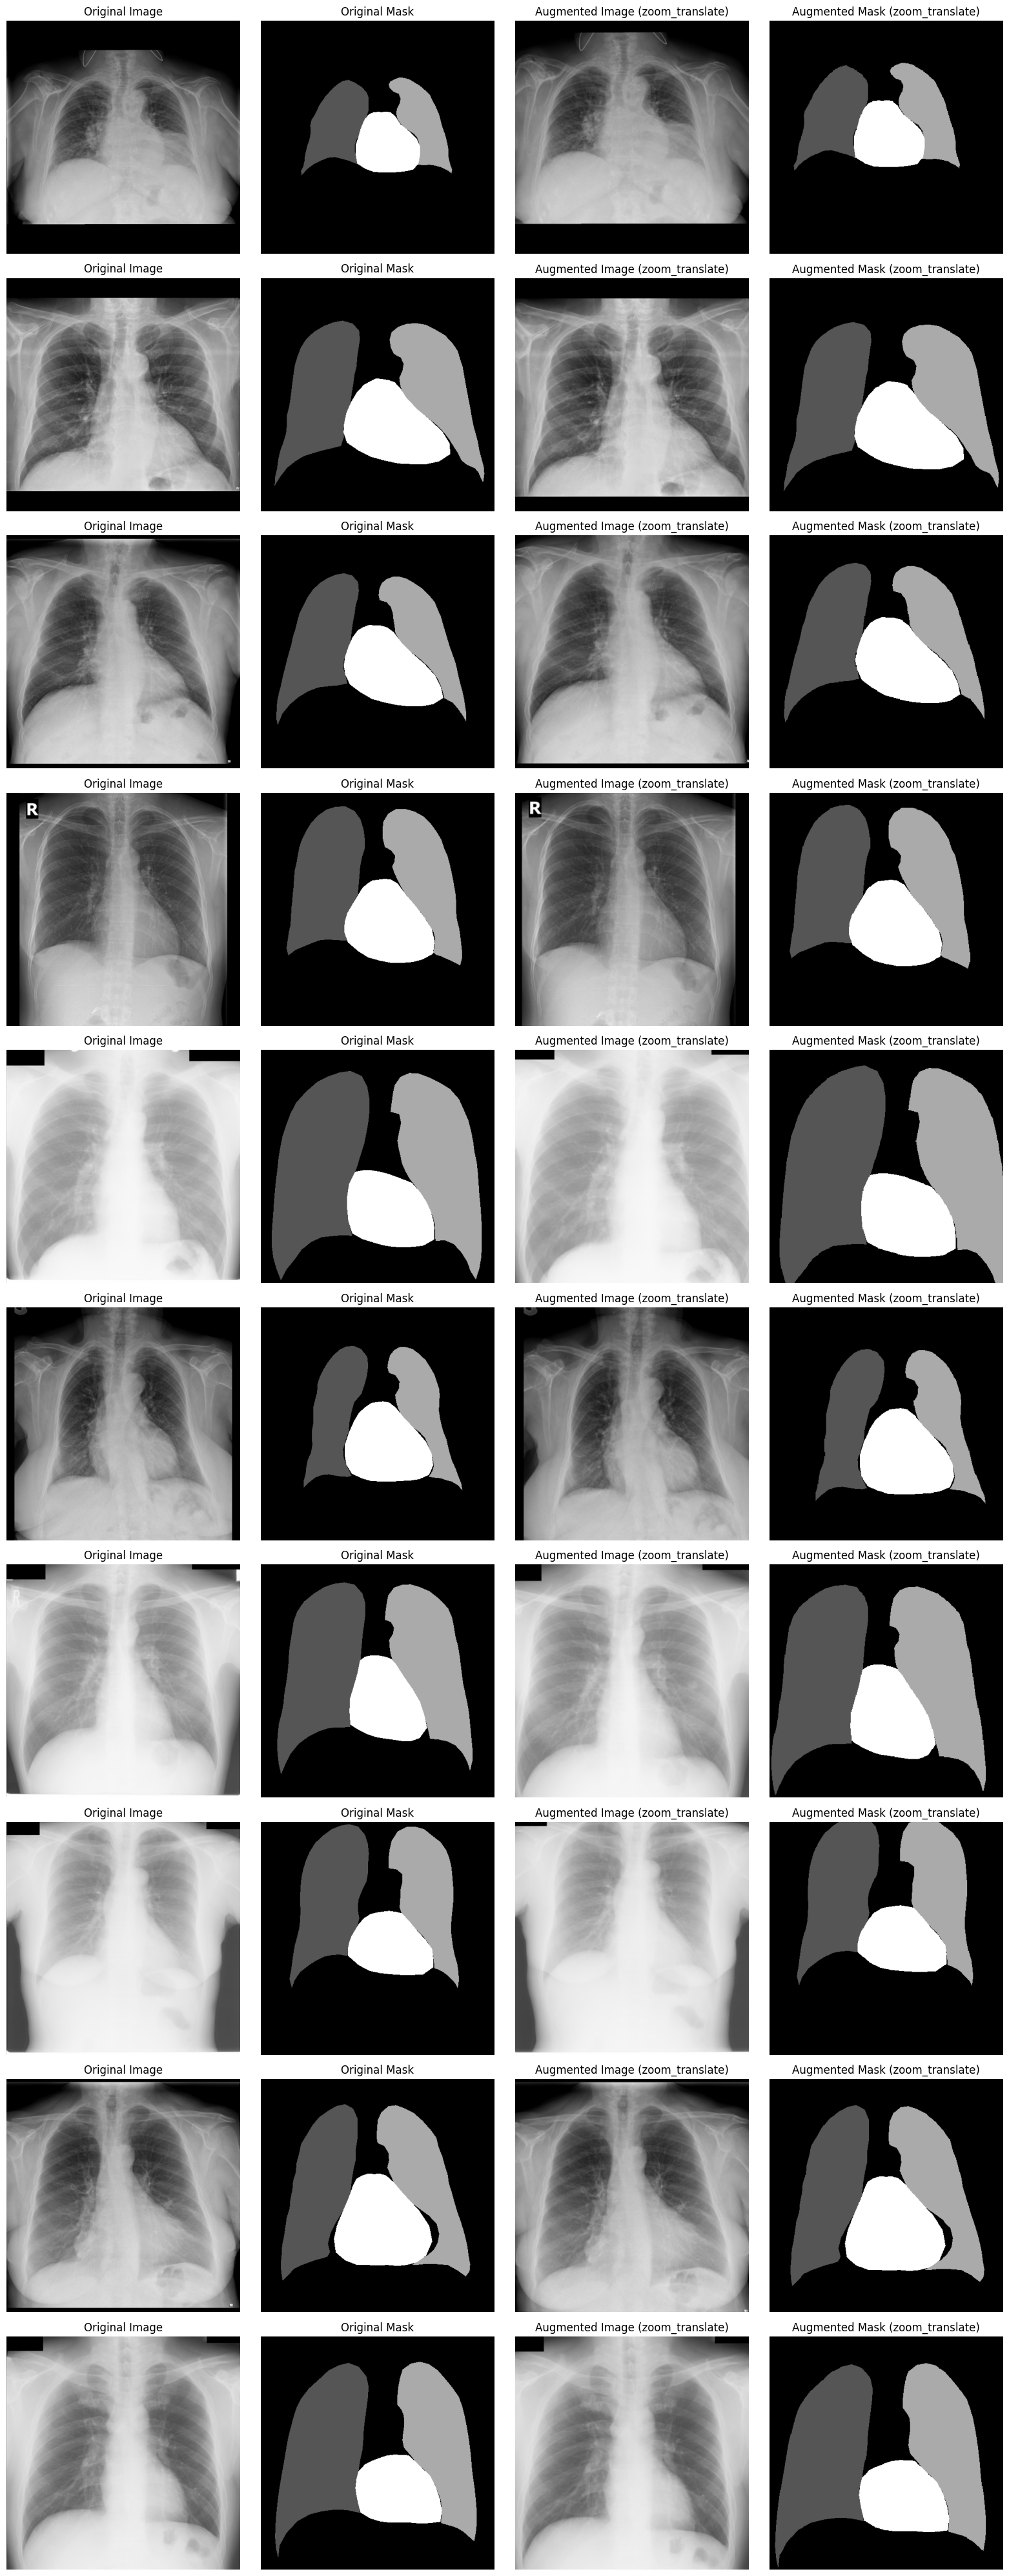

In [29]:
data_augmenter_traditional.visualize_augmentation(technique='zoom_translate', num_samples=10, zoom_range=(1.0, 1.1), translate_x_range=(-0.05, 0.05), translate_y_range=(-0.05, 0.05))

### augment

In [ ]:
copies_per_image = 4
augmentation_probabilities = {
                'gaussian_blur': 2,
                'grid_distortion': 1,
                'edge_enhancement': 3,
                'clarity': 4,
                'zoom_translate': 0
                }

In [49]:
data_augmenter_traditional.augment(copies_per_image=copies_per_image, augmentation_probabilities=augmentation_probabilities)

Using augmentation methods with custom probability weights: {'gaussian_blur': 2, 'grid_distortion': 1, 'edge_enhancement': 3, 'clarity': 4}

Augmentation complete!
Saved 383 original image-mask pairs
Generated 1532 augmented image-mask pairs
Total files in target folders: 1915 pairs

Augmentation technique usage counts:
- gaussian_blur: 383 times (25.0% of total augmentations)
- grid_distortion: 383 times (25.0% of total augmentations)
- edge_enhancement: 383 times (25.0% of total augmentations)
- clarity: 383 times (25.0% of total augmentations)


## augment traditionally augmented data by adjusting brightness

In [53]:
data_augmenter_brightness = DataAugmenterBrightness(
    CSV_PATH_AUGMENTED_TRADITIONAL, CSV_PATH_AUGMENTED_TRADITIONAL_BRIGHTNESS,
    F_DATA_AUGMENTED_TRADITIONAL_IMAGES, F_DATA_AUGMENTED_TRADITIONAL_MASKS,
    F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS_IMAGES, F_DATA_AUGMENTED_TRADITIONAL_BRIGHTNESS_MASKS
    )

In [71]:
copy_amount_dict = {
    8: (1,10),
    6: (11,20),
    4: (21,30),
    2: (31,40),
}
brightness_shift_limit = 50
min_brightness_shift_limit = 20
ctr_group_gap = 0.01
brightness_group_gap = 5
valid_brightness_range = (91, 224)

In [72]:
data_augmenter_brightness.augment(
    copy_amount_dict=copy_amount_dict,
    brightness_shift_limit=brightness_shift_limit,
    min_brightness_shift_limit=min_brightness_shift_limit,
    ctr_group_gap=ctr_group_gap,
    brightness_group_gap=brightness_group_gap,
    valid_brightness_range=valid_brightness_range
    )

Augmentation completed. Total images: 3053
Original images: 1915
Augmented images: 1138


## augment claned synthetic data by traditional methods & adjusting brightness

### traditional methods

In [53]:
data_augmenter_traditional = DataAugmenterTraditional(
    F_DATA_SYNTHETIC_CLEANED_IMAGES, F_DATA_SYNTHETIC_CLEANED_MASKS,
    F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_IMAGES, F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_MASKS
    )

In [54]:
data_augmenter_traditional.get_augmentation_info()

{'gaussian_blur': {'description': 'Apply Gaussian blur to image (mask unchanged)',
  'parameters': {'sigma_range': 'Range of sigma values (default: (0.5, 2.0))',
   'kernel_size_range': 'Range of kernel sizes, must be odd (default: (3, 9))'}},
 'grid_distortion': {'description': 'Apply smooth grid-based distortion to both image and mask',
  'parameters': {'grid_size_range': 'Range of grid divisions, higher=smoother (default: (8, 16))',
   'distortion_strength_range': 'Range of distortion strength 0-1, lower=less blocky (default: (0.05, 0.1))',
   'distortion_type': 'Type of distortion: random, wave, elastic (default: random)',
   'smoothness_factor': 'Smoothing factor for distortion field, higher=smoother (default: 2.5)'}},
 'edge_enhancement': {'description': 'Apply edge enhancement (sharpening) to image only (mask unchanged)',
  'parameters': {'kernel_strength_range': 'Range of kernel strength values (default: (0.2, 0.3))'}},
 'clarity': {'description': 'Enhances texture and fine det

In [55]:
copies_per_image = 1
augmentation_probabilities = {
                'gaussian_blur': 1,
                'grid_distortion': 3,
                'edge_enhancement': 1,
                'clarity': 2,
                'zoom_translate': 3
                }

In [56]:
data_augmenter_traditional.augment(copies_per_image=copies_per_image, augmentation_probabilities=augmentation_probabilities)

Using augmentation methods with custom probability weights: {'gaussian_blur': 1, 'grid_distortion': 3, 'edge_enhancement': 1, 'clarity': 2, 'zoom_translate': 3}

Augmentation complete!
Saved 1038 original image-mask pairs
Generated 1038 augmented image-mask pairs
Total files in target folders: 2076 pairs

Augmentation technique usage counts:
- gaussian_blur: 111 times (10.7% of total augmentations)
- grid_distortion: 308 times (29.7% of total augmentations)
- edge_enhancement: 86 times (8.3% of total augmentations)
- clarity: 211 times (20.3% of total augmentations)
- zoom_translate: 322 times (31.0% of total augmentations)


### brightness adjustment

In [63]:
data_augmenter_brightness = DataAugmenterBrightness(
    CSV_PATH_SYNTHETIC_CLEANED_TRADITIONAL, CSV_PATH_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS,
    F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_IMAGES, F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_MASKS,
    F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS_IMAGES, F_DATA_SYNTHETIC_CLEANED_TRADITIONAL_BRIGHTNESS_MASKS
    )

In [77]:
copy_amount_dict = {
    3: (1,20),
    2: (21,40),
    1: (61,100),
}
brightness_shift_limit = 50
min_brightness_shift_limit = 20
ctr_group_gap = 0.01
brightness_group_gap = 5
valid_brightness_range = (91, 224)

In [78]:
data_augmenter_brightness.augment(
    copy_amount_dict=copy_amount_dict,
    brightness_shift_limit=brightness_shift_limit,
    min_brightness_shift_limit=min_brightness_shift_limit,
    ctr_group_gap=ctr_group_gap,
    brightness_group_gap=brightness_group_gap,
    valid_brightness_range=valid_brightness_range
    )

Augmentation completed. Total images: 3039
Original images: 2076
Augmented images: 963
